# NanoTrade Latency Benchmark Analysis

Reads raw latency samples produced by `latency_benchmark` and plots distribution + CDF.

Run the benchmark first from the project root:
```
./cmake-build-release/latency_benchmark
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

RESULTS_DIR = '../benchmarks/results'

datasets = {
    'ME processClientRequest (mixed)': os.path.join(RESULTS_DIR, 'me_total_latency.csv'),
    'ME order add (no-cross, resting)': os.path.join(RESULTS_DIR, 'ob_add_latency.csv'),
}

samples = {label: pd.read_csv(path)['latency_ns'].values
           for label, path in datasets.items() if os.path.exists(path)}

In [2]:
summary_rows = []
for label, s in samples.items():
    summary_rows.append({
        'metric': label,
        'count': len(s),
        'min': int(np.min(s)),
        'p50': int(np.percentile(s, 50)),
        'p90': int(np.percentile(s, 90)),
        'p99': int(np.percentile(s, 99)),
        'p99.9': int(np.percentile(s, 99.9)),
        'max': int(np.max(s)),
        'mean': int(np.mean(s)),
    })
pd.DataFrame(summary_rows).set_index('metric')

,count,min,p50,p90,p99,p99.9,max,mean
metric,,,,,,,,
ME processClientRequest (mixed),500000,14691,82931,291236,540866,755803,4665890,136735
"ME order add (no-cross, resting)",500000,14675,74396,88126,118548,211142,513548,67572


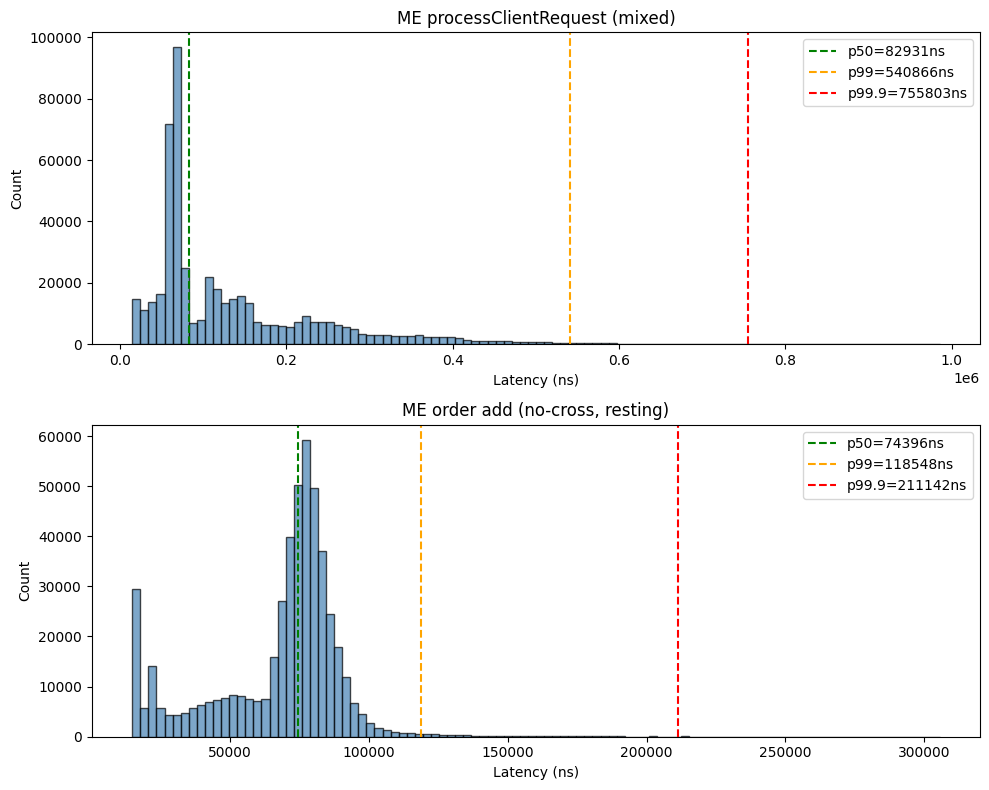

In [3]:
fig, axes = plt.subplots(len(samples), 1, figsize=(10, 4 * len(samples)))
if len(samples) == 1:
    axes = [axes]

for ax, (label, s) in zip(axes, samples.items()):
    upper = np.percentile(s, 99.99)
    clipped = s[s <= upper]
    ax.hist(clipped, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    for pct, color in [(50, 'green'), (99, 'orange'), (99.9, 'red')]:
        v = np.percentile(s, pct)
        ax.axvline(v, color=color, linestyle='--', label=f'p{pct}={int(v)}ns')
    ax.set_title(label)
    ax.set_xlabel('Latency (ns)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'latency_histogram.png'), dpi=120)
plt.show()

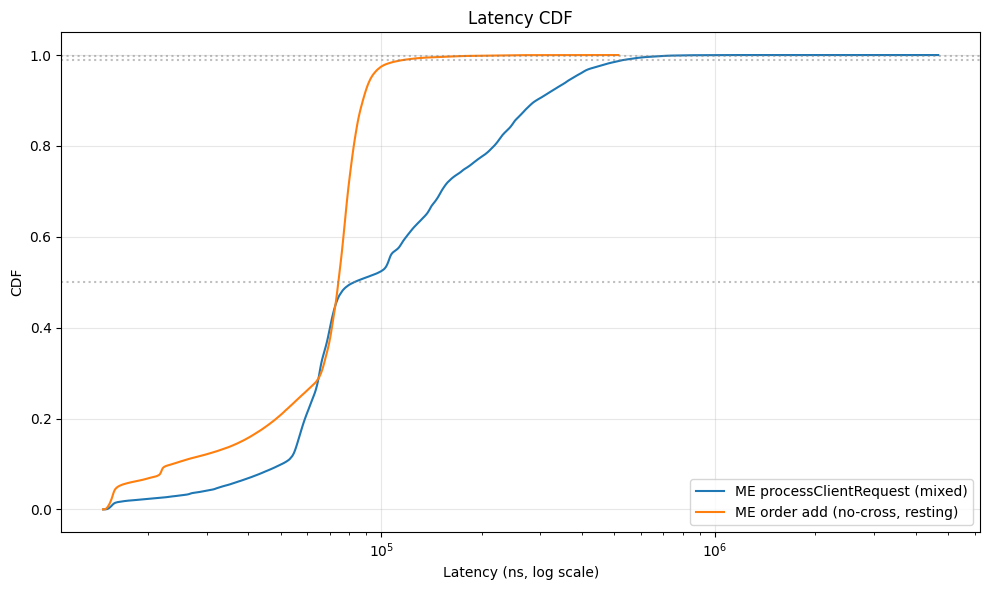

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, s in samples.items():
    sorted_s = np.sort(s)
    cdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
    ax.plot(sorted_s, cdf, label=label)

ax.set_xscale('log')
ax.set_xlabel('Latency (ns, log scale)')
ax.set_ylabel('CDF')
ax.set_title('Latency CDF')
for p in [0.50, 0.99, 0.999]:
    ax.axhline(p, color='gray', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'latency_cdf.png'), dpi=120)
plt.show()

## Debug vs Release Comparison

Compare the debug build (hot-path `logger_.log()` enabled, no optimization) against the release build
(`latency_benchmark_release`: `-O3 -march=native -DNT_BENCHMARK_NO_LOG`, P-core pinned).
Release compiles out ~11-15 log calls per order on the matching-engine hot path.

In [5]:
RESULTS_DIR_RELEASE = os.path.join(RESULTS_DIR, 'release')

datasets_release = {
    'ME processClientRequest (mixed)': os.path.join(RESULTS_DIR_RELEASE, 'me_total_latency.csv'),
    'ME order add (no-cross, resting)': os.path.join(RESULTS_DIR_RELEASE, 'ob_add_latency.csv'),
}

samples_release = {label: pd.read_csv(path)['latency_ns'].values
                   for label, path in datasets_release.items() if os.path.exists(path)}
list(samples_release.keys())

['ME processClientRequest (mixed)', 'ME order add (no-cross, resting)']

In [6]:
# Side-by-side: debug vs release percentiles with speedup factor.
rows = []
for label in samples_release:
    if label not in samples:
        continue
    d, r = samples[label], samples_release[label]
    for pct_label, pct in [('p50', 50), ('p90', 90), ('p99', 99), ('p99.9', 99.9)]:
        d_v = np.percentile(d, pct)
        r_v = np.percentile(r, pct)
        rows.append({
            'path': label,
            'pct': pct_label,
            'debug_ns': int(d_v),
            'release_ns': int(r_v),
            'speedup': f'{d_v / r_v:.0f}x',
        })
pd.DataFrame(rows)

,path,pct,debug_ns,release_ns,speedup
0,ME processClientRequest (mixed),p50,82931,121,680x
1,ME processClientRequest (mixed),p90,291236,344,844x
2,ME processClientRequest (mixed),p99,540866,613,881x
3,ME processClientRequest (mixed),p99.9,755803,1298,582x
4,"ME order add (no-cross, resting)",p50,74396,89,833x
5,"ME order add (no-cross, resting)",p90,88126,95,924x
6,"ME order add (no-cross, resting)",p99,118548,143,824x
7,"ME order add (no-cross, resting)",p99.9,211142,947,223x


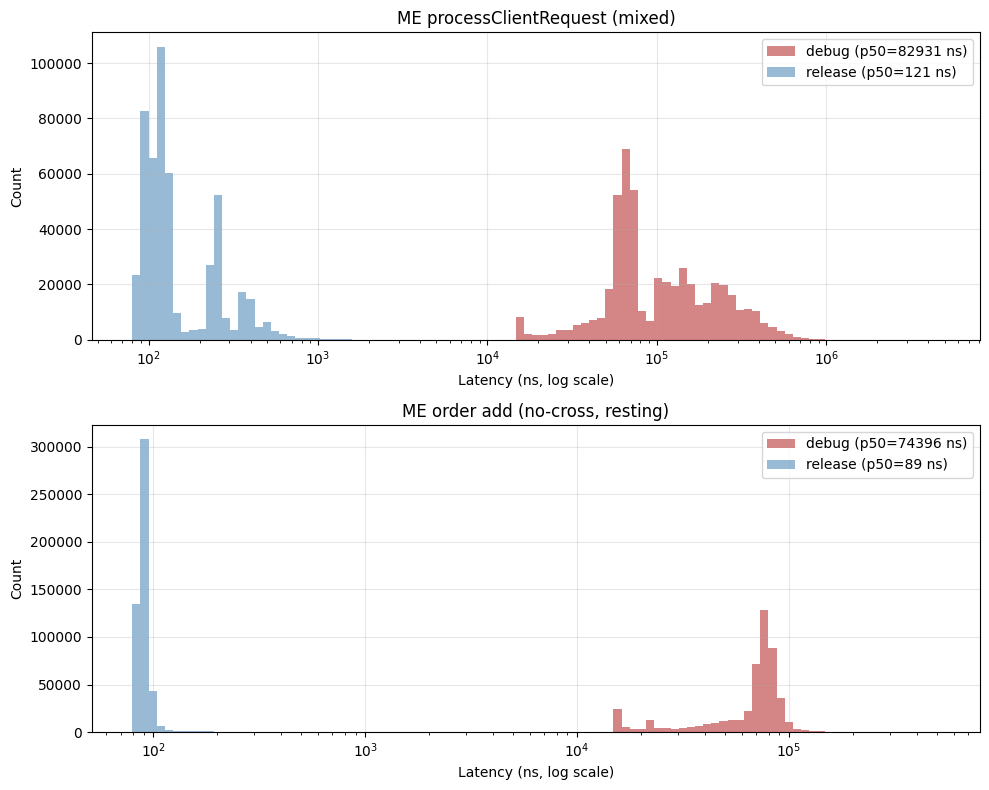

In [7]:
# Overlay histogram on log-x — the 3-order-of-magnitude separation is visible at a glance.
fig, axes = plt.subplots(len(samples_release), 1, figsize=(10, 4 * len(samples_release)))
if len(samples_release) == 1:
    axes = [axes]

for ax, label in zip(axes, samples_release):
    if label not in samples:
        continue
    d, r = samples[label], samples_release[label]
    lo, hi = min(d.min(), r.min()), max(d.max(), r.max())
    bins = np.logspace(np.log10(max(lo, 1)), np.log10(hi), 100)
    ax.hist(d, bins=bins, alpha=0.55, label=f'debug (p50={int(np.percentile(d, 50))} ns)', color='firebrick')
    ax.hist(r, bins=bins, alpha=0.55, label=f'release (p50={int(np.percentile(r, 50))} ns)', color='steelblue')
    ax.set_xscale('log')
    ax.set_xlabel('Latency (ns, log scale)')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'latency_debug_vs_release_hist.png'), dpi=120)
plt.show()

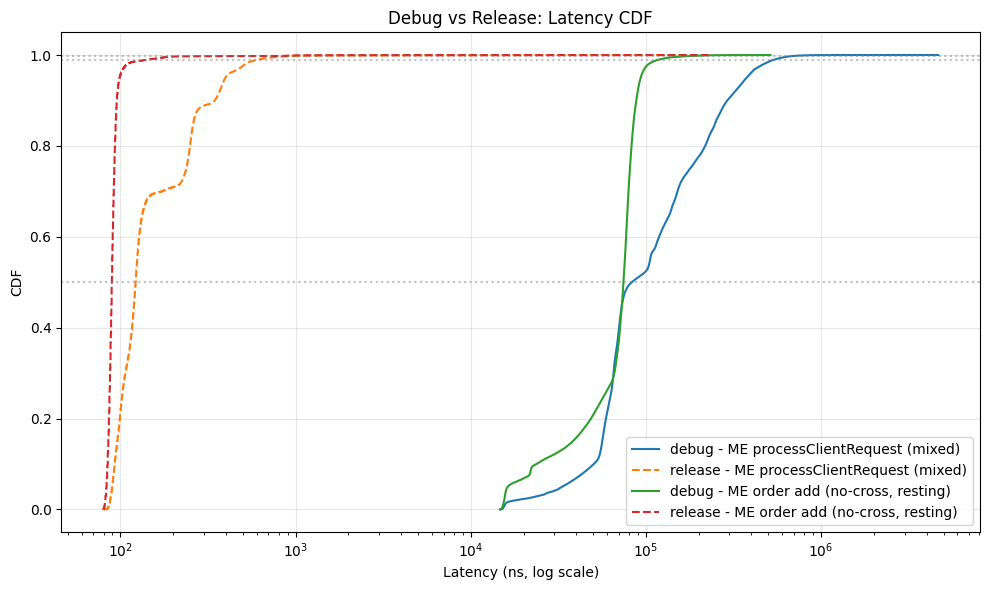

In [8]:
# Overlay CDF.
fig, ax = plt.subplots(figsize=(10, 6))
for label in samples_release:
    if label not in samples:
        continue
    for name, s, style in [('debug', samples[label], '-'), ('release', samples_release[label], '--')]:
        sorted_s = np.sort(s)
        cdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
        ax.plot(sorted_s, cdf, linestyle=style, label=f'{name} - {label}')

ax.set_xscale('log')
ax.set_xlabel('Latency (ns, log scale)')
ax.set_ylabel('CDF')
ax.set_title('Debug vs Release: Latency CDF')
for p in [0.50, 0.99, 0.999]:
    ax.axhline(p, color='gray', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'latency_debug_vs_release_cdf.png'), dpi=120)
plt.show()